# 02 — Factor Stability Analysis

**Goal:** Measure which factors have predictive value (IC analysis) before training the model.

The Information Coefficient (IC) = Spearman correlation between factor(season N) and fpts_per_game(season N+1).

Strong factors → include in Ridge model  
Weak factors → downweight or exclude

Expected results:
- STRONG: target_share, rush_share, air_yard_share, wopr, team_pass_rate
- MODERATE: catch_rate, aDOT, epa_per_dropback (QB), cpoe, yac_per_rec
- WEAK: TD rates, INT rates, explosive_play_rate, stuff_rate

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TRAINING_SEASONS, POSITION_FEATURES, POSITIONS
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.stability import (
    compute_factor_stability,
    compute_yoy_factor_correlation,
    plot_stability_heatmap,
    plot_factor_ic_bar,
)

print('Imports OK')

Imports OK


## 1. Build Feature Matrix

In [2]:
# Assemble the full 5-year feature matrix
# This will take a few minutes on first run (heavy PBP processing)
print('Building feature matrix...')
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
print(f'Feature matrix: {feature_matrix.shape}')
print(f'\nRows per position:')
print(feature_matrix.groupby(['position', 'season']).size().unstack(fill_value=0))

Building feature matrix...
Assembling feature matrix for seasons: [2020, 2021, 2022, 2023, 2024]
  Computing opportunity factors...
  Computing efficiency factors...
  Computing context factors...
  Computing trend factors...
  Merging factors...
  Computing situation change features...
  Computing pedigree features...
  Computing consistency features...
  Feature matrix: 1452 rows, 127 columns
  Saving to cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Feature matrix: (1452, 127)

Rows per position:
season    2020  2021  2022  2023  2024
position                              
QB          44    44    48    50    46
RB          83    88    79    78    80
TE          46    46    45    44    46
WR         119   120   114   115   117


In [3]:
# Build YoY pairs (season N features → season N+1 target)
yoy = build_yoy_pairs(feature_matrix)
print(f'YoY pairs: {len(yoy)}')
print(f'\nPairs per position:')
print(yoy.groupby(['position', 'season']).size().unstack(fill_value=0))

YoY pairs: 814

Pairs per position:
season    2020  2021  2022  2023
position                        
QB          30    36    31    31
RB          61    56    56    59
TE          31    28    33    33
WR          83    80    82    84


## 2. IC Analysis — All Factors

In [4]:
# All factors in the feature matrix (excluding metadata columns)
meta_cols = ['player_id', 'player_name', 'position', 'team', 'season', 'age',
             'fpts', 'fpts_per_game', 'games_played', 'next_fpts', 'trend_class']
all_factors = [c for c in yoy.columns if c not in meta_cols]
print(f'Factors to evaluate: {len(all_factors)}')

Factors to evaluate: 117


In [5]:
# Compute IC for all factors
stability = compute_factor_stability(yoy, all_factors)
print(stability[['mean_ic', 'std_ic', 'ic_ir', 'stability_tier']].to_string())

                                mean_ic    std_ic      ic_ir     stability_tier
factor                                                                         
weekly_fpts_median             0.686780  0.012725  53.970958             STRONG
consistency_score              0.525035  0.027792  18.891611           MODERATE
snap_percentage                0.524175  0.031112  16.848075           MODERATE
weekly_fpts_std                0.468806  0.008229  56.969468           MODERATE
dropbacks                      0.428253  0.122965   3.482721           MODERATE
draft_capital_score            0.376985  0.029822  12.641179           MODERATE
dropbacks_per_game             0.376209  0.106065   3.546961           MODERATE
pass_td_rate                   0.369943  0.046144   8.017096           MODERATE
boom_rate                      0.369145  0.016962  21.763523           MODERATE
pass_yards_per_attempt         0.353850  0.056825   6.226961           MODERATE
draft_round_bucket             0.350307 

In [6]:
# IC IR summary
print('Factors with IC IR > 1.0 (strong signal):')
print(stability[stability['ic_ir'] > 1.0][['mean_ic', 'ic_ir', 'stability_tier']])

print('\nFactors with IC IR < 0.5 (weak signal — consider excluding):')
print(stability[stability['ic_ir'] < 0.5][['mean_ic', 'ic_ir', 'stability_tier']])

Factors with IC IR > 1.0 (strong signal):
                         mean_ic      ic_ir stability_tier
factor                                                    
weekly_fpts_median      0.686780  53.970958         STRONG
consistency_score       0.525035  18.891611       MODERATE
snap_percentage         0.524175  16.848075       MODERATE
weekly_fpts_std         0.468806  56.969468       MODERATE
dropbacks               0.428253   3.482721       MODERATE
draft_capital_score     0.376985  12.641179       MODERATE
dropbacks_per_game      0.376209   3.546961       MODERATE
pass_td_rate            0.369943   8.017096       MODERATE
boom_rate               0.369145  21.763523       MODERATE
pass_yards_per_attempt  0.353850   6.226961       MODERATE
draft_round_bucket      0.350307  12.086363       MODERATE
target_share_late       0.334105  12.235703       MODERATE
target_share_early      0.327284   8.264859       MODERATE
targets_per_game        0.314354   8.670959       MODERATE
targets_recv  

## 3. IC Heatmap (Factor × Season)

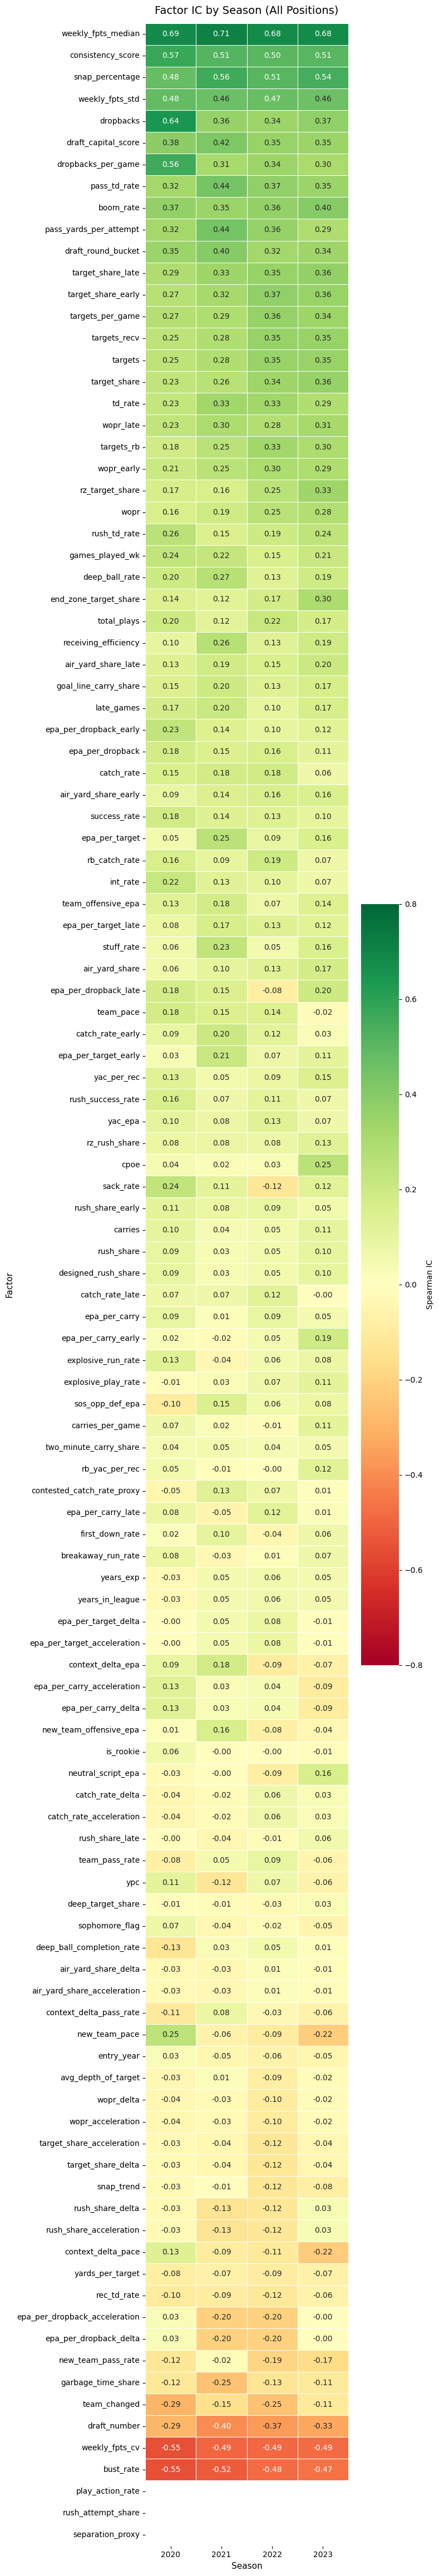

In [7]:
fig = plot_stability_heatmap(stability, title='Factor IC by Season (All Positions)')
plt.show()

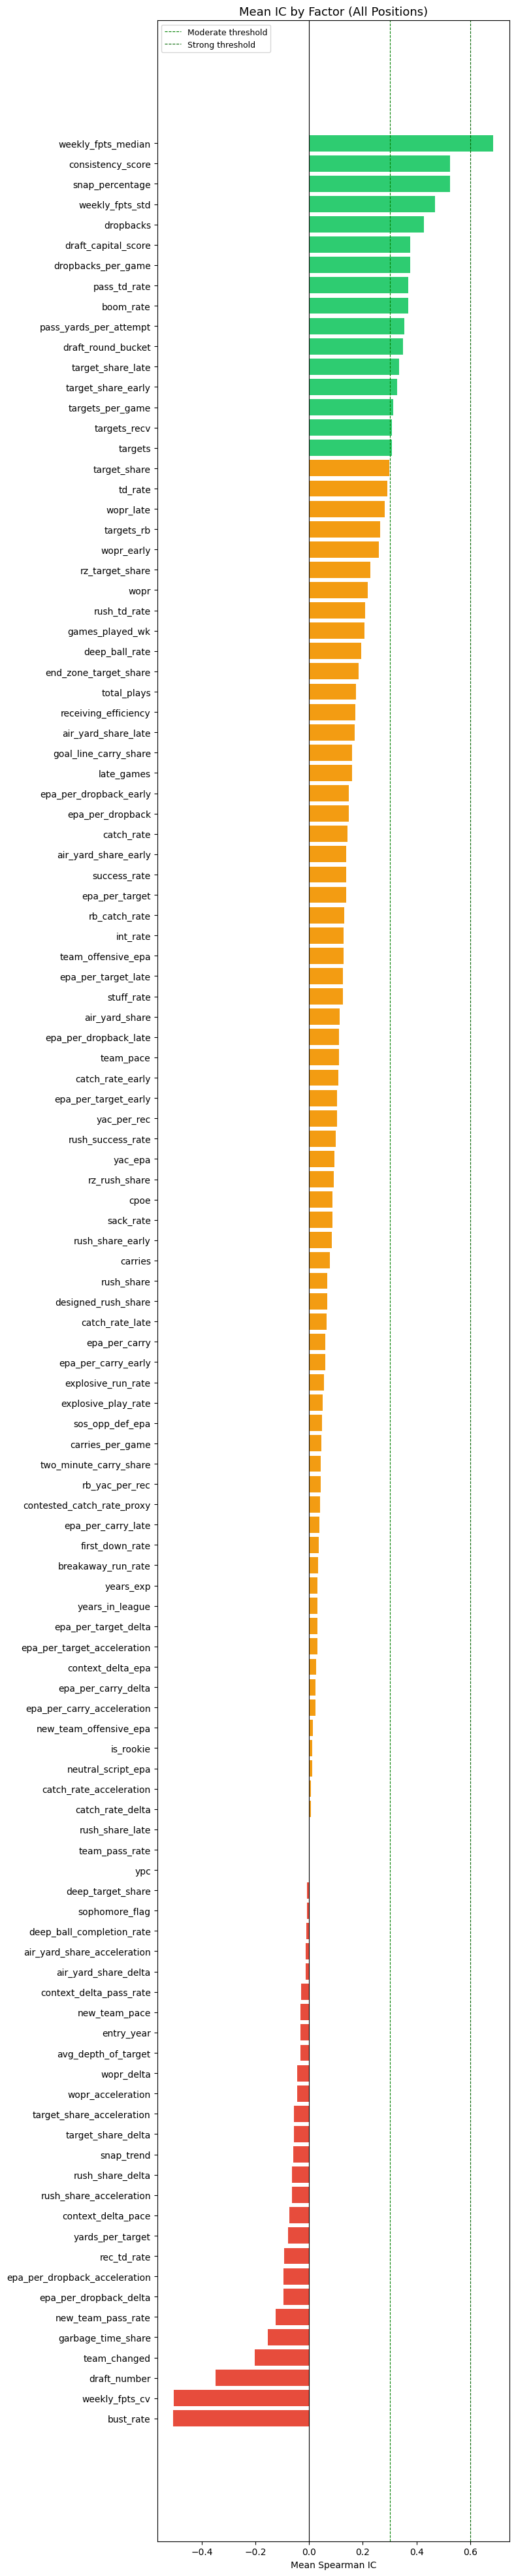

In [8]:
fig = plot_factor_ic_bar(stability, title='Mean IC by Factor (All Positions)')
plt.show()

## 4. Position-Specific IC Analysis

In [9]:
for pos in POSITIONS:
    pos_yoy = yoy[yoy['position'] == pos]
    if len(pos_yoy) < 10:
        continue
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_yoy.columns]
    pos_stability = compute_factor_stability(pos_yoy, pos_factors)
    
    print(f'\n=== {pos} IC Analysis ===')
    print(pos_stability[['mean_ic', 'std_ic', 'ic_ir', 'stability_tier']].to_string())


=== QB IC Analysis ===
                     mean_ic    std_ic     ic_ir     stability_tier
factor                                                             
td_rate             0.431684  0.088448  4.880679           MODERATE
epa_per_dropback    0.422805  0.162091  2.608437           MODERATE
games_played        0.371408  0.149135  2.490418           MODERATE
cpoe                0.330072  0.138986  2.374857           MODERATE
team_pace           0.229092  0.098404  2.328077               WEAK
deep_ball_rate      0.214973  0.152426  1.410337               WEAK
years_in_league    -0.008909  0.199047 -0.044757               WEAK
int_rate           -0.157386  0.126631 -1.242870               WEAK
sack_rate          -0.216527  0.029766 -7.274365               WEAK
team_changed       -0.356252  0.082322 -4.327521           MODERATE
weekly_fpts_cv     -0.393306  0.243956 -1.612198           MODERATE
rush_attempt_share       NaN       NaN       NaN  INSUFFICIENT DATA
target_share_delta      

## 5. YoY Factor Stickiness (Factor-to-Factor)

In [10]:
# How stable are the factors themselves year-over-year?
# This is different from IC (which measures factor → outcome).
# High YoY correlation = the factor is a persistent player characteristic.
yoy_corr = compute_yoy_factor_correlation(feature_matrix, all_factors)
print('YoY factor correlation (factor persistence):')
print(yoy_corr[['pearson_yoy', 'spearman_yoy', 'n_pairs', 'yoy_tier']].head(20).to_string())

YoY factor correlation (factor persistence):
                      pearson_yoy  spearman_yoy  n_pairs yoy_tier
factor                                                           
years_exp                1.000000      1.000000      814   STRONG
draft_round_bucket       1.000000      1.000000      814   STRONG
draft_number             1.000000      1.000000      733   STRONG
entry_year               1.000000      1.000000      814   STRONG
draft_capital_score      1.000000      1.000000      814   STRONG
years_in_league          0.999626      1.000000      814   STRONG
dropbacks_per_game       0.943807      0.756173      155   STRONG
avg_depth_of_target      0.916483      0.894860      693   STRONG
carries_per_game         0.898255      0.899504      542   STRONG
air_yard_share           0.870534      0.884354      695   STRONG
air_yard_share_early     0.827593      0.859755      621   STRONG
rush_share               0.827352      0.899371      542   STRONG
designed_rush_share      0.8273

## 6. Factor Correlation Matrix (Multicollinearity Check)

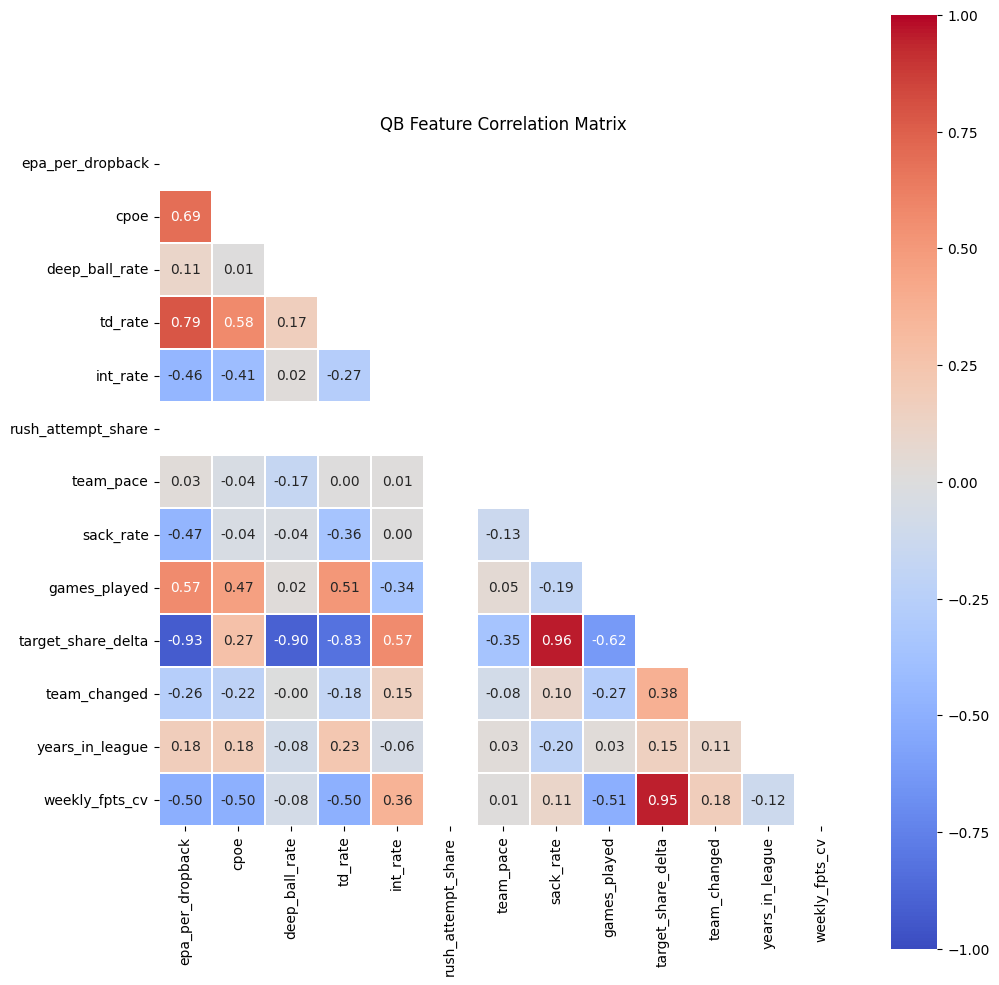

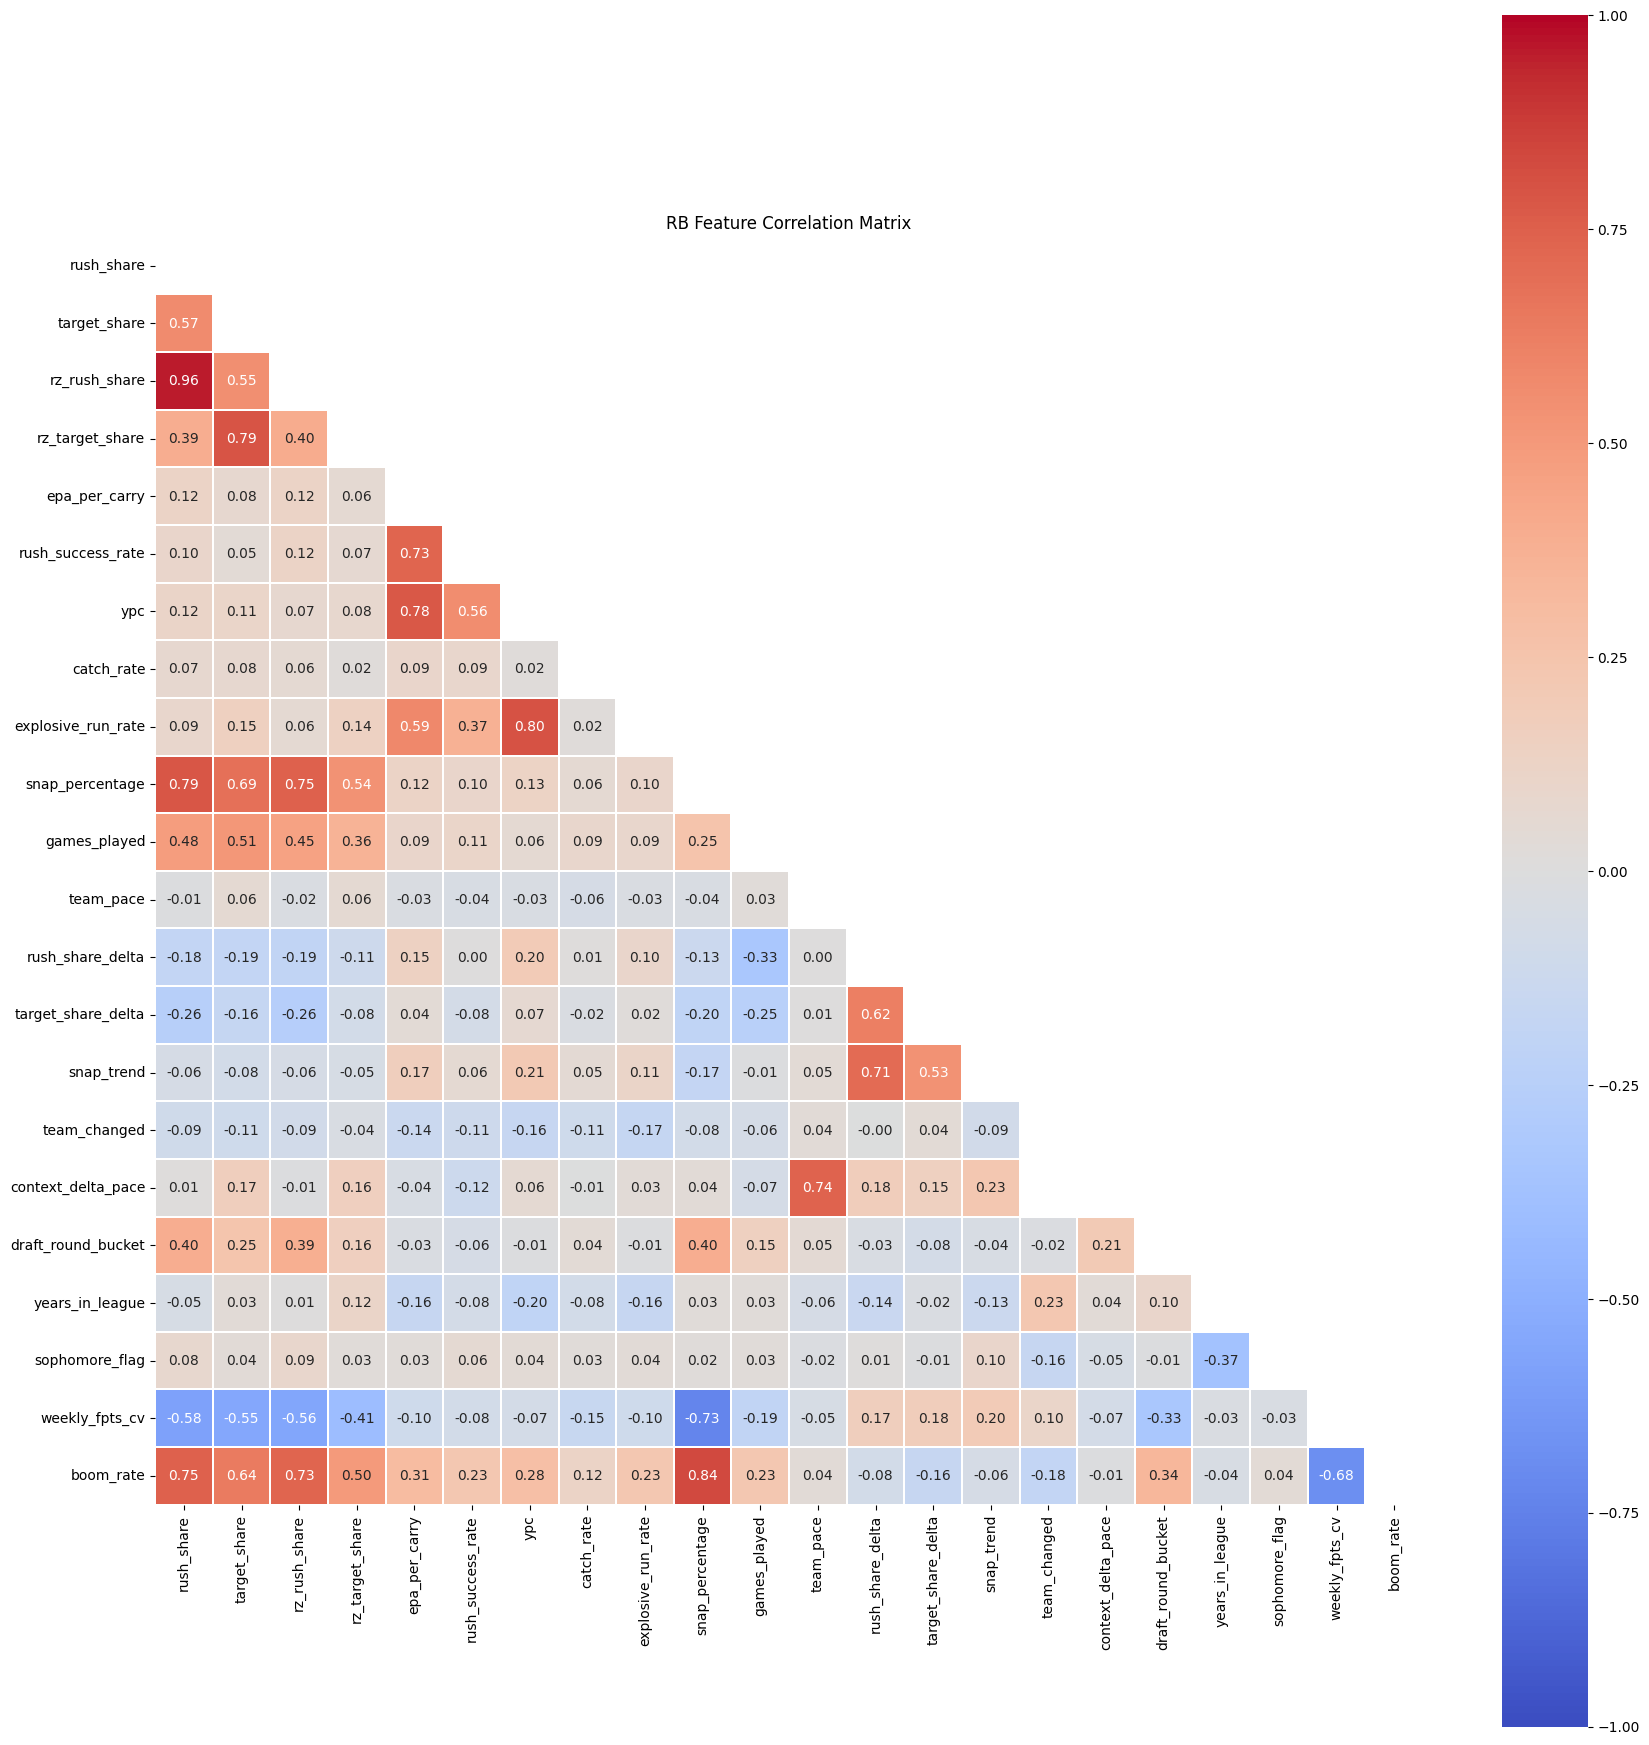

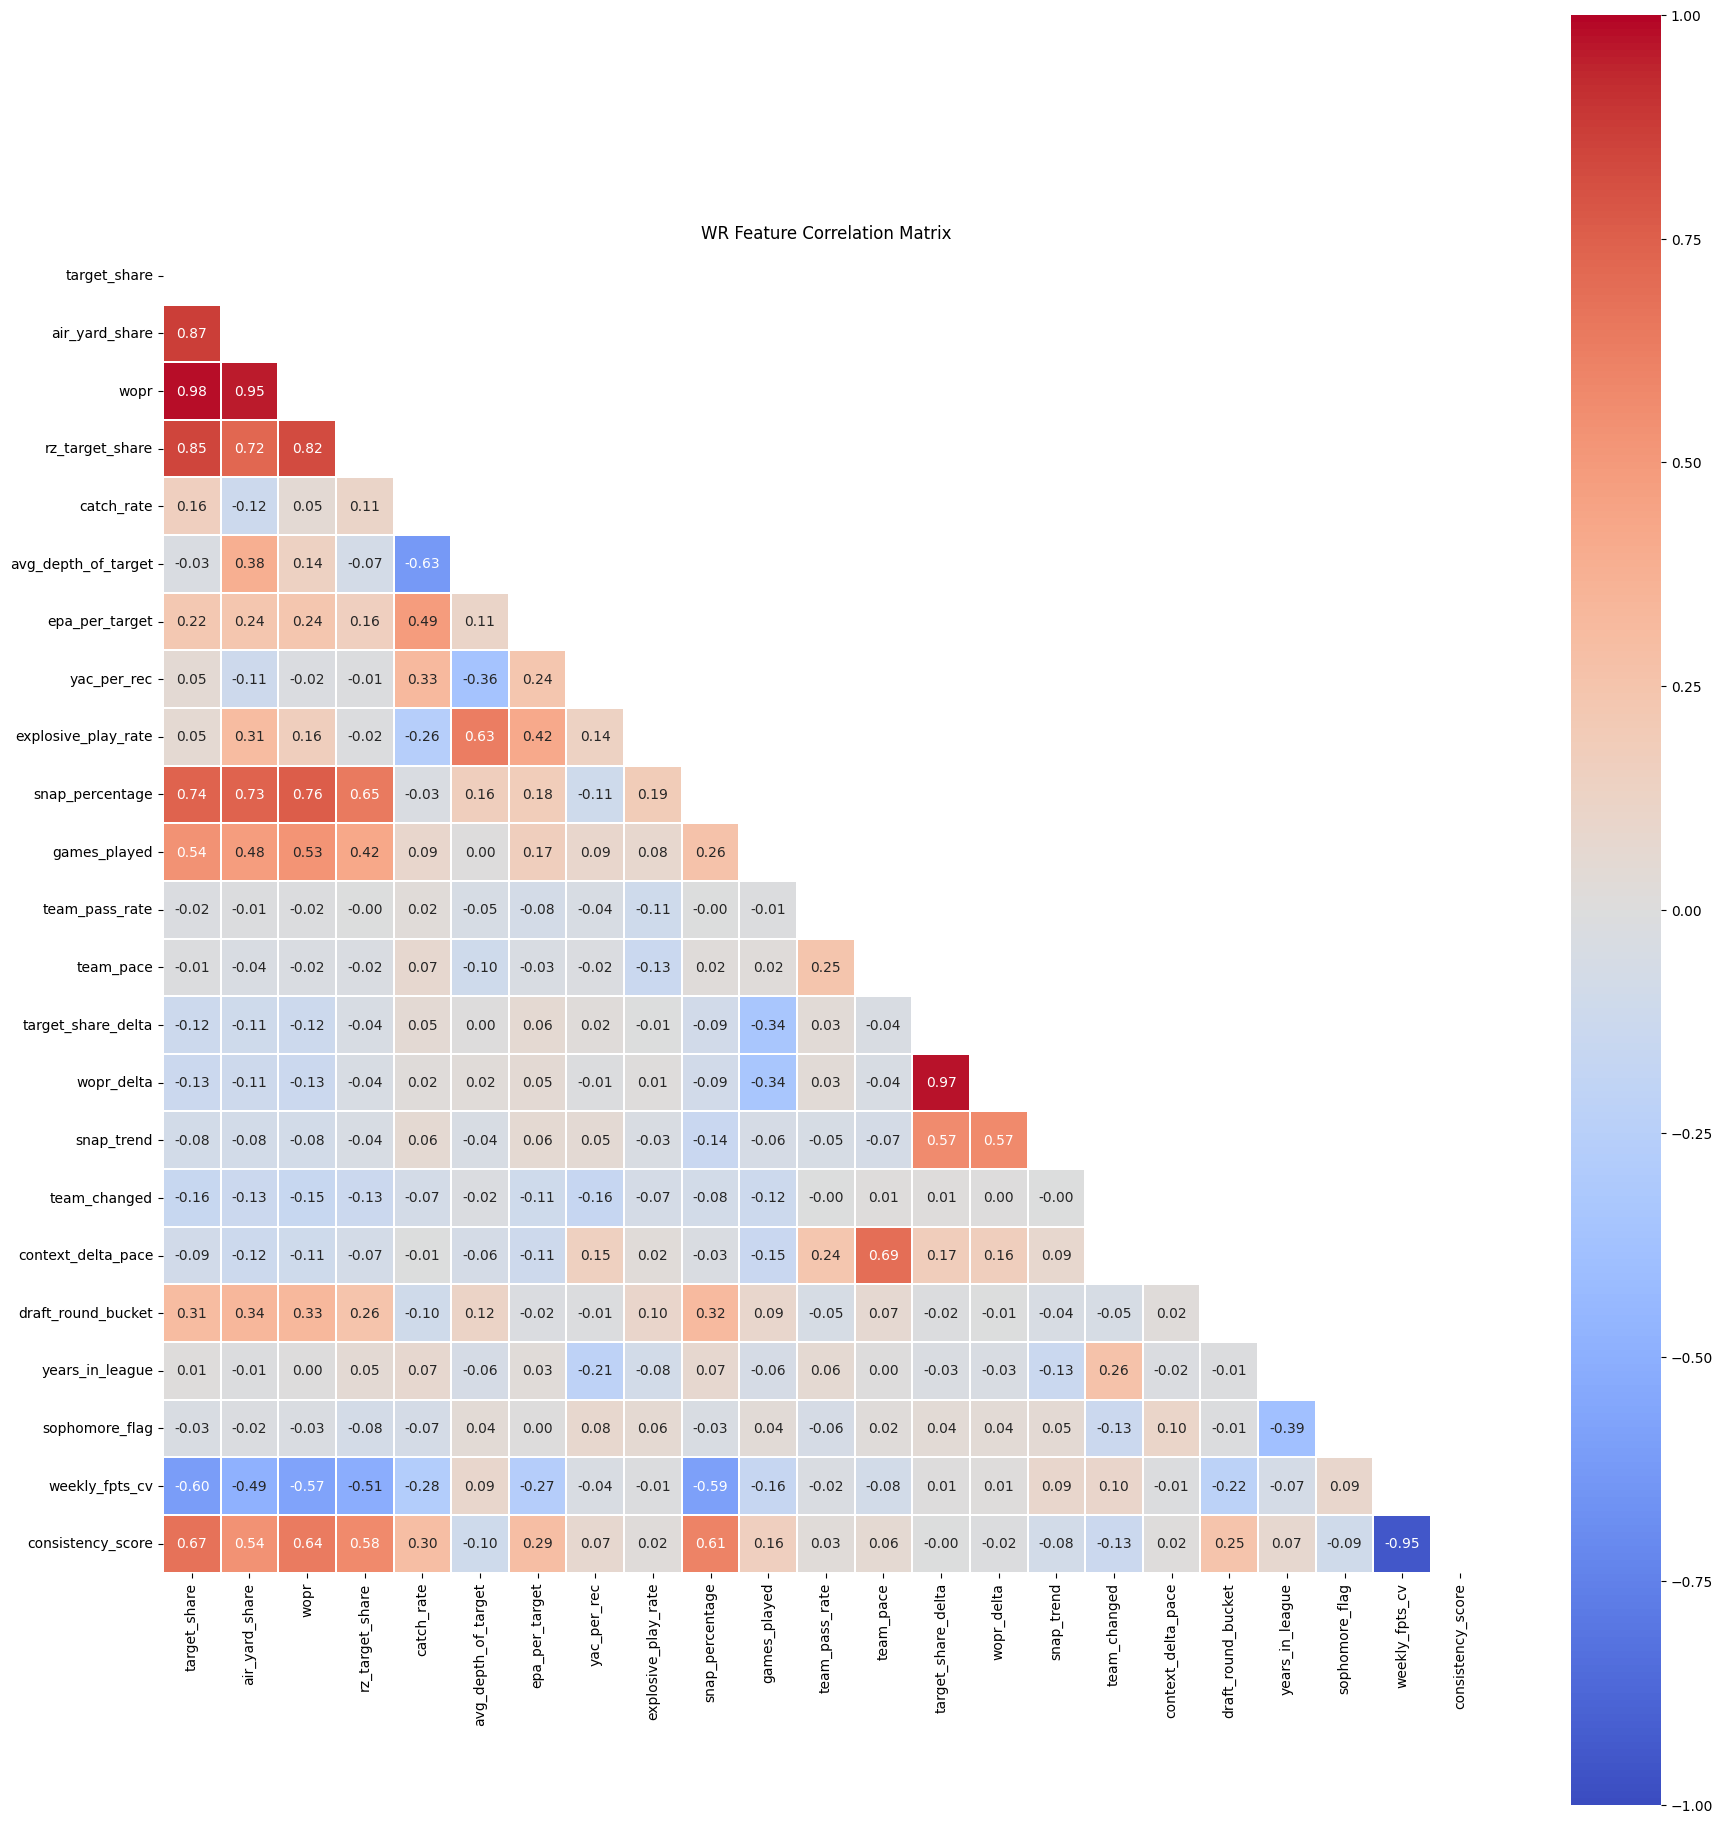

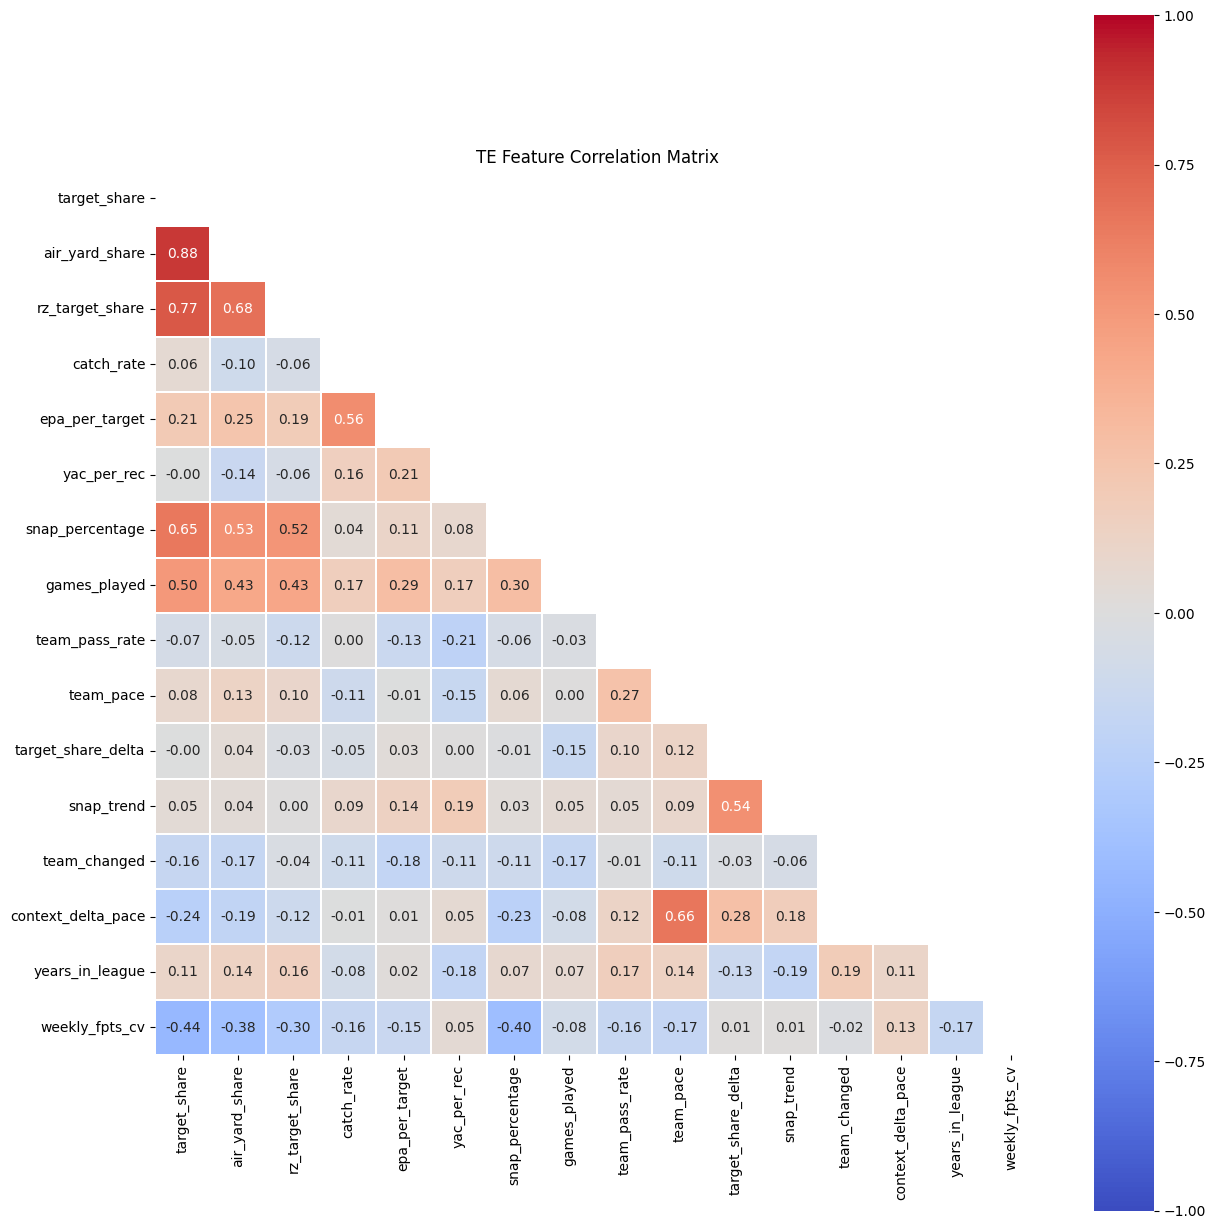

In [11]:
# Check correlation among model features (high correlation = potential multicollinearity)
# Ridge regression handles this, but it's useful to know
for pos in POSITIONS:
    pos_data = feature_matrix[feature_matrix['position'] == pos]
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_data.columns]
    
    corr_matrix = pos_data[pos_factors].corr()
    
    fig, ax = plt.subplots(figsize=(max(6, len(pos_factors) * 0.8), max(5, len(pos_factors) * 0.8)))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, ax=ax, cmap='coolwarm',
        center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
        square=True, linewidths=0.3
    )
    ax.set_title(f'{pos} Feature Correlation Matrix', fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Top Factors — Scatter Plots

Plot top 3 most stable factors vs. next-year PPR for each position.

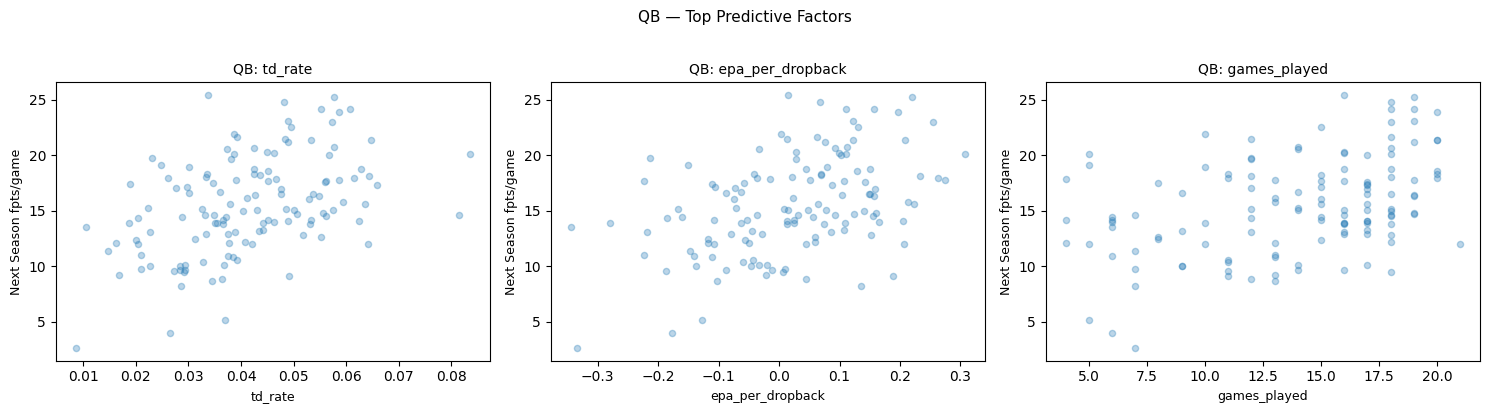

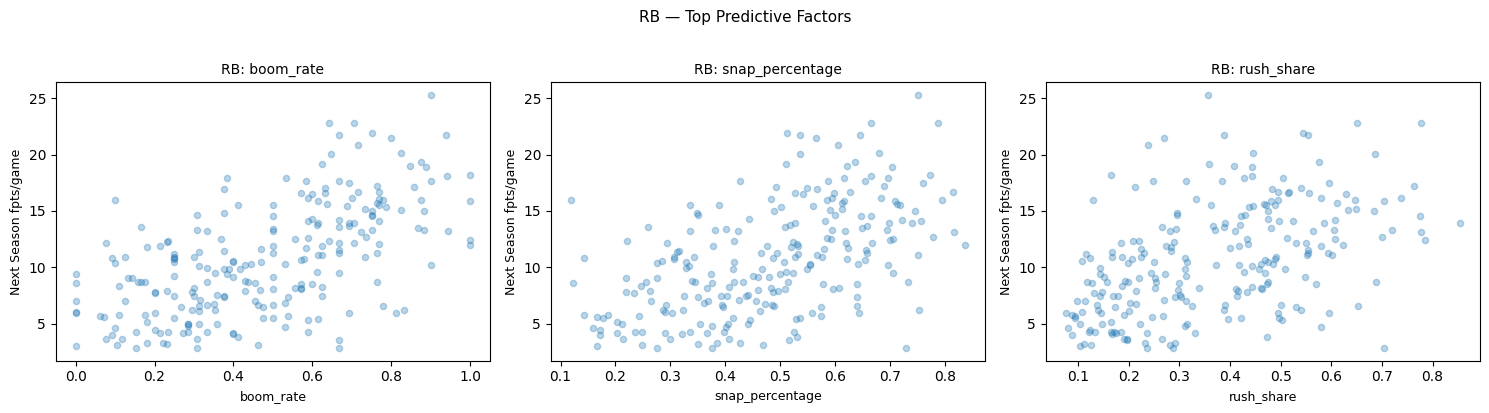

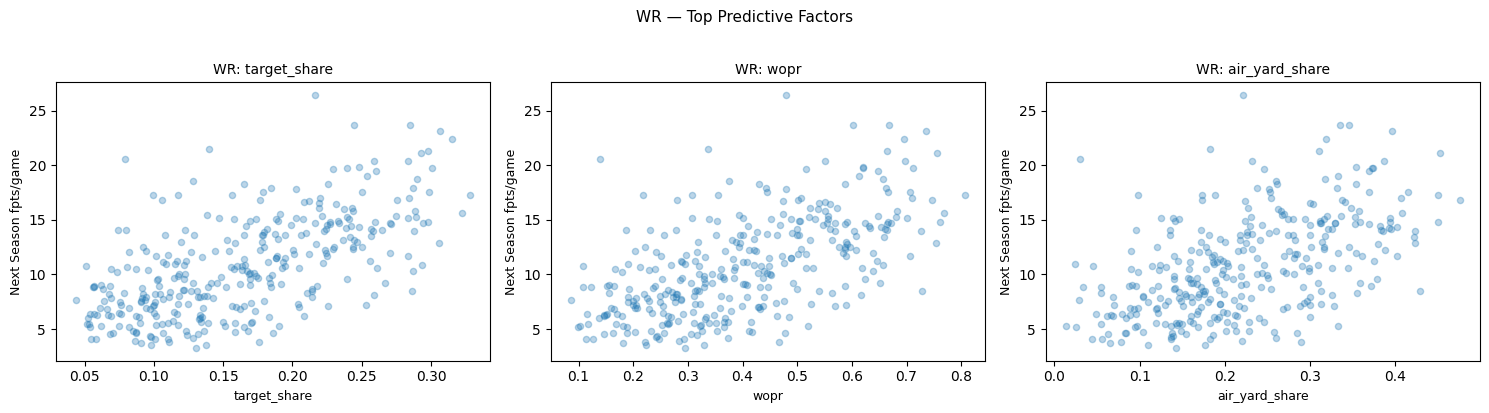

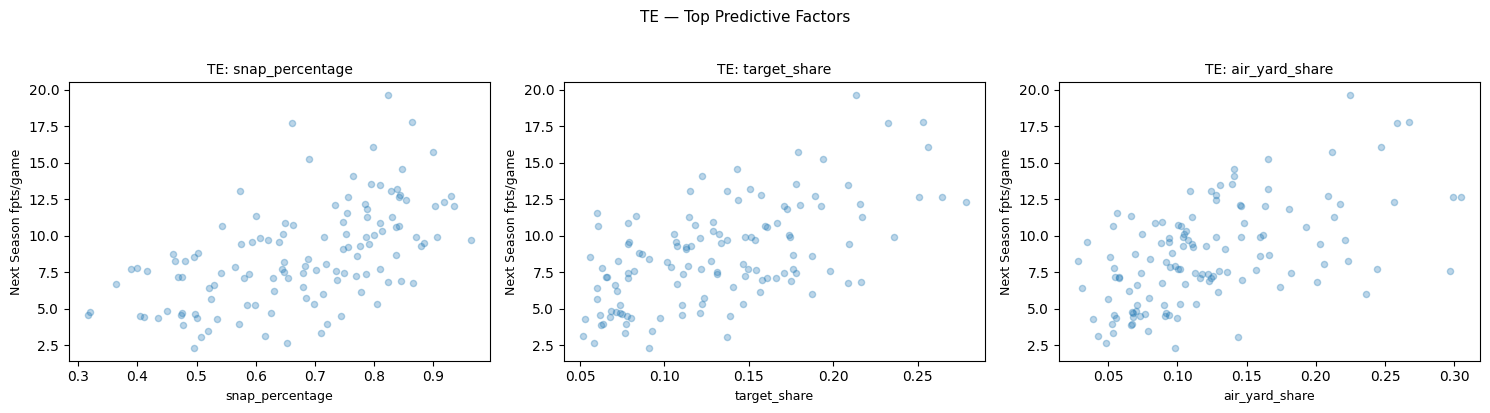

In [12]:
for pos in POSITIONS:
    pos_yoy = yoy[yoy['position'] == pos].dropna(subset=['next_fpts'])
    if len(pos_yoy) < 10:
        continue
    
    pos_factors = [f for f in POSITION_FEATURES[pos] if f in pos_yoy.columns]
    pos_stability = compute_factor_stability(pos_yoy, pos_factors)
    top3 = pos_stability.dropna(subset=['mean_ic']).head(3).index.tolist()
    
    if not top3:
        continue
    
    fig, axes = plt.subplots(1, min(3, len(top3)), figsize=(5 * min(3, len(top3)), 4))
    if len(top3) == 1:
        axes = [axes]
    
    for ax, factor in zip(axes, top3):
        valid = pos_yoy[[factor, 'next_fpts']].dropna()
        ax.scatter(valid[factor], valid['next_fpts'], alpha=0.3, s=20)
        ax.set_xlabel(factor, fontsize=9)
        ax.set_ylabel('Next Season fpts/game', fontsize=9)
        ax.set_title(f'{pos}: {factor}', fontsize=10)
    
    plt.suptitle(f'{pos} — Top Predictive Factors', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. v3 New Feature IC Analysis

IC analysis for the three new v3 feature groups:
- **QB coupling**: `qb_epa_per_dropback`, `qb_cpoe`, `qb_changed`, `qb_upgrade_delta`
- **Vacated shares**: `team_vacated_target_share`, `team_vacated_carry_share`, `top_departed_target_share`
- **Top-down team constraint**: `topdown_fpts_pg` (WR/TE only)

These features are only present in the v3 feature matrix. Re-run with `force_recompute=True` if they are missing.

In [ ]:
# v3 new features to evaluate
V3_NEW_FEATURES = [
    # QB coupling
    'qb_epa_per_dropback', 'qb_cpoe', 'qb_changed', 'qb_upgrade_delta', 'qb_td_rate',
    # Vacated shares
    'team_vacated_target_share', 'team_vacated_carry_share', 'top_departed_target_share',
    # Top-down team constraint
    'topdown_fpts_pg',
]

# Only include features that are present in yoy
v3_available = [f for f in V3_NEW_FEATURES if f in yoy.columns]
v3_missing = [f for f in V3_NEW_FEATURES if f not in yoy.columns]
print(f'v3 features available: {v3_available}')
if v3_missing:
    print(f'v3 features missing (need force_recompute=True): {v3_missing}')

In [ ]:
# IC analysis for v3 features
if v3_available:
    v3_stability = compute_factor_stability(yoy, v3_available)
    print('v3 Feature IC Summary:')
    print(v3_stability[['mean_ic', 'std_ic', 'ic_ir', 'pct_positive']].to_string())
    print()
    print('Interpretation:')
    print('  mean_ic > 0.05 = useful signal')
    print('  ic_ir > 0.5 = consistent signal')
    print('  pct_positive > 60% = reliable direction')
else:
    print('No v3 features available. Re-run assemble_feature_matrix(force_recompute=True).')

In [ ]:
# Position-specific IC for QB coupling features (WR and TE benefit most)
qb_features = [f for f in ['qb_epa_per_dropback', 'qb_cpoe', 'qb_changed'] if f in yoy.columns]
if qb_features:
    print('QB coupling IC by position:')
    for pos in ['WR', 'TE', 'RB']:
        pos_yoy = yoy[yoy['position'] == pos]
        if len(pos_yoy) < 20:
            continue
        pos_stab = compute_factor_stability(pos_yoy, qb_features)
        print(f'  {pos}:')
        print(pos_stab[['mean_ic', 'ic_ir']].to_string())
else:
    print('QB coupling features not in yoy.')

In [ ]:
# Position-specific IC for vacated share features
vacated_features = [f for f in ['team_vacated_target_share', 'team_vacated_carry_share', 'top_departed_target_share'] if f in yoy.columns]
if vacated_features:
    print('Vacated share IC by position:')
    for pos in ['WR', 'TE', 'RB']:
        pos_yoy = yoy[yoy['position'] == pos]
        if len(pos_yoy) < 20:
            continue
        pos_stab = compute_factor_stability(pos_yoy, vacated_features)
        print(f'  {pos}:')
        print(pos_stab[['mean_ic', 'ic_ir']].to_string())
else:
    print('Vacated share features not in yoy.')

In [ ]:
# Topdown fpts IC for WR and TE
if 'topdown_fpts_pg' in yoy.columns:
    print('topdown_fpts_pg IC by position:')
    for pos in ['WR', 'TE']:
        pos_yoy = yoy[yoy['position'] == pos].dropna(subset=['topdown_fpts_pg'])
        if len(pos_yoy) < 10:
            print(f'  {pos}: insufficient data (n={len(pos_yoy)})')
            continue
        pos_stab = compute_factor_stability(pos_yoy, ['topdown_fpts_pg'])
        row = pos_stab.iloc[0]
        print(f'  {pos}: mean_ic={row["mean_ic"]:.3f}, ic_ir={row["ic_ir"]:.3f}, pct_pos={row["pct_positive"]:.1%}')
else:
    print('topdown_fpts_pg not in yoy.')

In [ ]:
# Bar chart: v3 features IC comparison
if v3_available:
    fig, ax = plt.subplots(figsize=(8, max(3, len(v3_available) * 0.4)))
    colors = ['#2ecc71' if ic > 0 else '#e74c3c' for ic in v3_stability['mean_ic']]
    ax.barh(v3_stability.index, v3_stability['mean_ic'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(0.05, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label='IC=0.05 threshold')
    ax.set_xlabel('Mean IC (all positions)')
    ax.set_title('v3 New Features — Information Coefficient')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()